In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.interpolate
import math
import lab_funcs as lf
import my_funcs as mf

# Методы численного интегрирования

## Задание 1
Рассмотрим интеграл $$I=\int_{-1}^5\frac{dx}{1+9x^2}.$$

1. Вычислите значение интеграла аналитически.

2. Реализуйте методы численного интегрирования по формулам трапеций и Симпосона, или используйте готовые реализации из scipy.
Вычислите по этим формулам интеграл $I$ и оцените погрешности для разного числа интервалов. Определите скорость убывания погрешностей, сравните их с теоретическими значениями. Изобразите результаты сравнения на графике.

3. Воспользуйтесь правилом Рунге для оценке длины шага по методу трапеций, необходимого для получения $I$ с абсолютной погрешностью менее $10^{-6}$. Сравните полученную оценку длины шага с фактической длиной шага, необходимой для достижения указанной точности.

4. Повторите оценку шага по правилу Рунге для формулы Симпсона.

5. Для интервала $[-1,1]$ напишите программу, вычисляющую веса формул Ньютона-Котеса с равноотстоящими узлами. Проверьте выполнение свойств весов: нормировки и симметричности. Для какого числа узлов впервые появляются отрицательные веса?

### Решение 1

#### 1.
 $$I = \frac13 \arctg{3x} {|}_{-1}^{5}=\frac13(\arctg{15} + \arctg{3})\approx \boxed{0,91776}$$

#### 2.
##### 2.1 Формула трапеции:

Для $N = 1$: $$I = \frac12(f(a)+f(b))(b-a)$$

Для $N \ge 1$ (Состовная формула): $$I = h(\frac{f(a)}2+f(a+h)+\dots+f(b-h)+\frac{f(b)}2)$$

Погрешность мы будем брать из формулы Эйлера-Маклорена:

$$ \sum_{k=0}^{N}f(x_k) = \frac{1}{h} \int_a^b f(x) dx + \frac{f(a)+f(b)}{2} + \sum_{m=1}^p \frac{B_{2m}}{(2m)!}h^{2m-1}(f^{(2m-1)}(b) - f^{(2m-1)}(a)) + R_p$$

- $h = \frac{b-a}{N}$
- $x_k = a +kh$
- $B_{2m}$ - Bernulli
- $R_p = \frac{h^{2p+1}}{(2p+2)!}
\int_0^N \widetilde{B}_{2p+2}(t)\, f^{(2p+2)}(a+ht)\,dt.$ 

Получим оценку для $p=1$ (самая простая считаемая оценка):
$$ \int_a^b f(x) dx = T_N - \frac{h^2}{12}(f'(b) - f'(a)) + R_1$$
$$R_1 = \frac{h^4}{720}\int_0^NB_4(t)f^{(4)}(a+ht)dt \approx C_1 h^{4} \max_{x \in [a;b]}|f^{(4)}(x)|$$
$$T_N = h \cdot (\frac{f(a)}{2} + \sum_{k=1}^{N-1}f(x_k) + \frac{f(b)}{2})$$
$$I - T_N = - \frac{h^2}{12}(f'(b) - f'(a)) + O(h^4)$$

Слагаемое $O(h^4)$ не учитываем, т.к. при больших $N$ оно не играет особой роли. Т.е. при $h^4 \approx 10^{-16} \rightarrow N \ge (\frac{(b-a)^4}{10^{-16}})^{\frac{1}{4}} =  60000$ последнее влагаемое не играет роли в численном методе.

В итоге погрешность для формулы трапеции имеет вид (не учитывая слагаемое $O(h^4)$):
$$f'(a)= 0.18, f'(b) = -0.00176 \Rightarrow \boxed{|R|\leq 0.54528/N^2}$$

Вычислительная погрешность $\sim \epsilon N$


##### 2.2 Формула Симпсона:
Получается данная формула из разложения на интерполяционный многочлен Лагранжа и последующего его интегрирования
$$I \approx \int_{x_0}^{x_2} P_2(x) d x = f(x_0)\int_{x_0}^{x_2}L_0(x) d x + f(x_1)\int_{x_0}^{x_2}L_1(x) d x + f(x_2)\int_{x_0}^{x_2}L_2(x) d x = \frac{(b- a)}{3*2} (f(a) + 4*f(a+h) + f(b))$$

Составная получается разбиениена четное количество отрезков и применением формулы к каждой паре:
$$I \approx \frac{b-a}{3*N} ( f(a) + 4 \cdot \sum_{odd \; i} f(x_i) + 2 \cdot \sum_{even \;  i} f(x_i) + f(b) )$$

Формула погрешшности для формулы Симпсона получается из раздожения функции в ряд Тейлора до 5-го слагаемого около середины интервала и последующего интегрирования. После нахождение разности между ф-ой Симпсона, разложенного в Тейлора в точке середины, и предыдущего ряда. Для расширения на N интервалов, домножаем на $\frac{N}{2}$ - количество парных интервалов:
$$ |R|\leq \frac1{180}\max\limits_{[a, b]}|f^{(4)}|(b-a)^5/N^4 $$

Получаем следующую погрешность:
$$f^{(4)}=\frac{23328x^2}{(1+9x^2)^3}+18(1-9x^2)(\frac{1944x^2}{(1+9x^2)^4}-\frac{36}{(1+9x^2)^3}), \max\limits_{[a, b]}|f^{(4)}|=972 \Rightarrow \boxed{|R|\leq 41990/N^4}$$

Но это грубая оценка, получим более точную оценку. Формула не получится из суммы Эйлера-Маклорена. Хотя если подставить тотже коэффициент, но при этом учесть степень, то получим отлиный результат $\boxed{|R|\leq 0.54528/N^4}$.

Для получения более точной оценки, надо искать $\max|f^{(4)}|$ на каждом интервалле $[x_i; x_{i+1}]$ отдельно. Для этого получим формулу для $f^{(4)}$
$$f^{(4)} = \dfrac{1944\,\left(405\,{x}^{4}-90\,{x}^{2}+1\right)}{59049\,{x}^{10}+32805\,{x}^{8}+7290\,{x}^{6}+810\,{x}^{4}+45\,{x}^{2}+1}$$

Вычислительная погрешность $\sim \epsilon N$

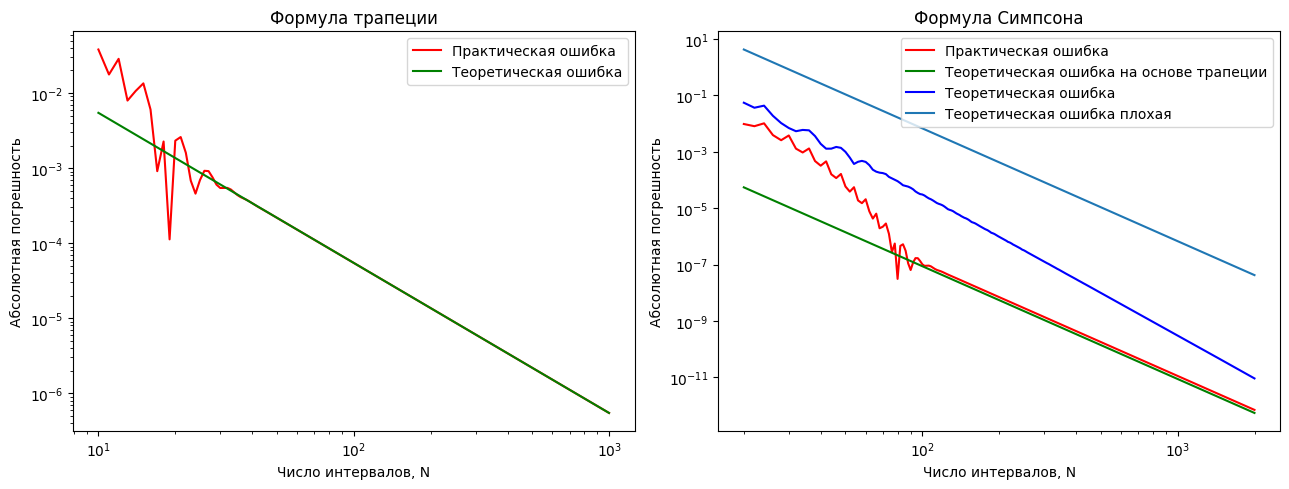

In [3]:
I = (np.arctan(15)+np.arctan(3))/3
a, b = -1, 5


def f(x):
    return 1/(1+9*x*x)

def f_d4(x):
    return 1944*(405*np.power(x,4) - 90*np.power(x,2) + 1) / (59049*np.power(x,10) + 32805*np.power(x,8) + 7290*np.power(x,6) + 810*np.power(x,4) + 45*np.power(x,2) + 1)


def get_I_by_trapez(f, N, a=-1, b=5):
    h = (b-a)/N
    f0 = [f(a + n*h) for n in range(1, N)]
    return h*(0.5*f(a) + np.sum(f0)+ 0.5*f(b))

def get_teor_err_trapez(N):
    return 0.54528/np.power(N,2)


def get_I_by_simps(f, N, a=-1, b=5):
    h = (b-a)/N
    f0 = [f(a + n*h) for n in range(1, N)]
    return (h/3)*(f(a) + 4*np.sum(f0[0::2]) + 2*np.sum(f0[1::2]) + f(b))

def get_teor_err_simons_by_trapez_err(N):
    return 0.54528/np.power(N,4) #41990/np.power(N,4)

def get_bad_teor_err_simons(N):
    return 41990/np.power(N,4)

def get_teor_err_simons(N, a, b, f):
    n = 10

    maxs_for_N = []
    errs = np.empty(N.shape)

    h = (b - a) / N
    maxima = np.empty(N)

    for i in range(N):
        left = a + i * h
        right = left + h

        x = np.linspace(left, right, n)
        y = f(x)

        maxima[i] = np.max(y)

    maxs_for_N.append(maxima)

    errs = (1/180)*(np.power(h, 5)/np.power(2, 4))*np.sum(maxs_for_N)

    return errs

Ns = np.arange(10, 1000)
errs_tr = np.empty(Ns.shape)
errs_tr_teor = np.empty(Ns.shape)

errs_s = np.empty(Ns.shape)
errs_s_teor_by_trapes = np.empty(Ns.shape)
errs_s_teor = np.empty(Ns.shape)
errs_s_teor_bad = np.empty(Ns.shape)


for i in range(Ns.shape[0]):
    errs_tr[i] = lf.get_abs_err(get_I_by_trapez(f, Ns[i]), I)
    errs_tr_teor[i] = get_teor_err_trapez(Ns[i])

    errs_s[i] = lf.get_abs_err(get_I_by_simps(f, 2 * Ns[i]), I)
    errs_s_teor_by_trapes[i] = get_teor_err_simons_by_trapez_err(Ns[i])
    errs_s_teor[i] = get_teor_err_simons(Ns[i], a, b, f_d4)
    errs_s_teor_bad[i] = get_bad_teor_err_simons(Ns[i])


fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].loglog(Ns, errs_tr, 'r', label='Практическая ошибка')
ax[0].loglog(Ns, errs_tr_teor, 'g', label='Теоретическая ошибка')
ax[0].set_xlabel('Число интервалов, N')
ax[0].set_ylabel('Абсолютная погрешность')
ax[0].set_title('Формула трапеции')
ax[0].legend()

ax[1].loglog(Ns*2, errs_s, 'r', label='Практическая ошибка')
ax[1].loglog(Ns*2, errs_s_teor_by_trapes, 'g', label='Теоретическая ошибка на основе трапеции')
ax[1].loglog(Ns*2, errs_s_teor, 'b', label='Теоретическая ошибка')
ax[1].loglog(Ns*2, errs_s_teor_bad, label='Теоретическая ошибка плохая')
ax[1].set_xlabel('Число интервалов, N')
ax[1].set_ylabel('Абсолютная погрешность')
ax[1].set_title('Формула Симпсона')
ax[1].legend()

fig.tight_layout()

#### 3.
##### 3.1 Правило Рунге:
Метод имеет порядок $p$, его ошибка имеет вид:
$$R(h)=C \cdot h^p+o(h^p)$$
Тогда:
$$I - I_h = C \cdot h^p$$
$$I - I_{h/2} = C \cdot (h/2)^p$$
Отсюдаполучаем формулу для оценки абсолютной ошибки:
$$ I - I_{h/2} \approx \frac{I_{h/2} - I_h}{2^p - 1} $$

Для интегрирования через трапецию получаем ($p = 2$):

$$ I - I_{h/2} \approx \frac{I_{h/2} - I_h}{3} $$


##### 3.2 Реализация для трапеции:
Реализуем чтобы поллучить абсолютную погрешность $10^{-6}$

Искомая точность достигается при числе шагов 1024 и шаге 5.859375e-03


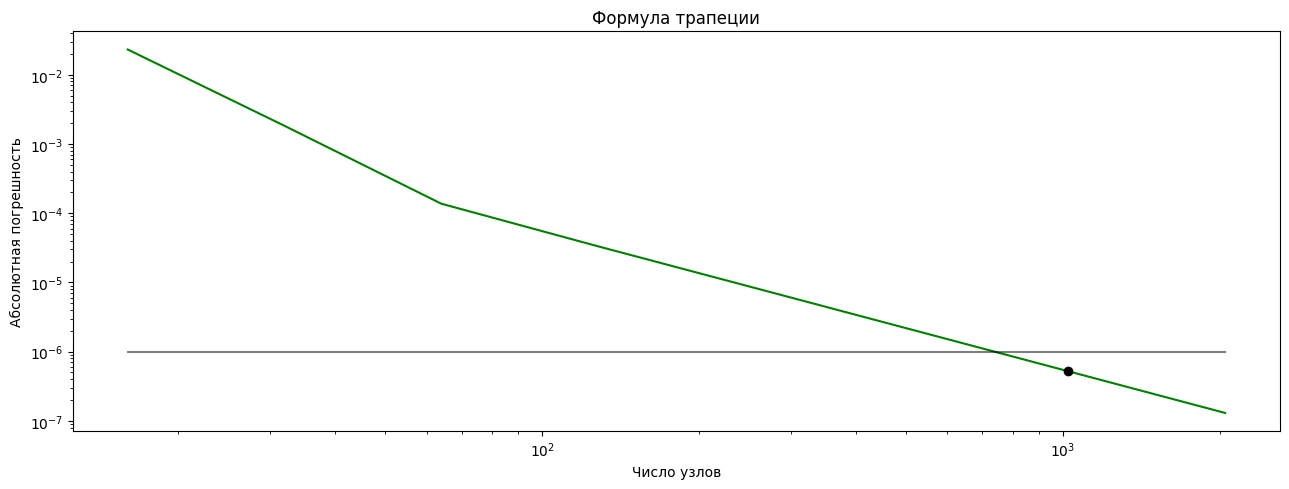

In [4]:
prec = 10**(-6)

runge_n = 2**np.arange(3, 12)
runge_err_t = np.empty(runge_n.shape[0])
r_t = 0

for i in range(1, runge_n.shape[0]):
    runge_err_t[i] = lf.get_abs_err(get_I_by_trapez(f, runge_n[i]), get_I_by_trapez(f, runge_n[i-1]))/3

    if (runge_err_t[i] < prec) and (runge_err_t[i-1] > prec):
        r_t = i


print(f'Искомая точность достигается при числе шагов {runge_n[r_t]} и шаге {6/runge_n[r_t]:e}')

fig, ax = plt.subplots(1, 1, figsize=(13, 5))
ax.loglog(runge_n[1:], runge_err_t[1:], 'g')
ax.loglog(runge_n[1:], prec*np.ones(runge_n.shape[0])[1:], 'k', alpha=0.5)
ax.loglog(runge_n[r_t], runge_err_t[r_t], 'o', mfc='k', mec='k')
ax.set_xlabel('Число узлов')
ax.set_ylabel('Абсолютная погрешность')
ax.set_title('Формула трапеции')


fig.tight_layout()

#### 4.
##### 4.1 Правило Рунге для Симпсона:

Для интегрирования через Симпсона получаем ($p = 4$):

$$ I - I_{h/2} \approx \frac{I_{h/2} - I_h}{15} $$


##### 4.2 Реализация для Симпсона:
Реализуем чтобы поллучить абсолютную погрешность $10^{-6}$

Искомая точность достигается при числе шагов 256 и шаге 2.343750e-02 соответственно для формулы Симпсона


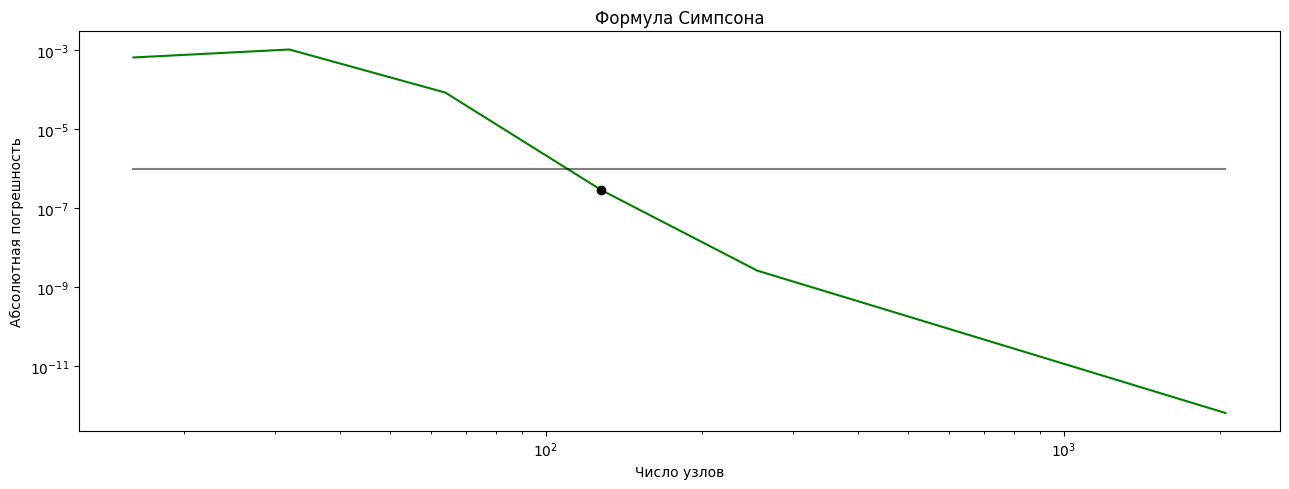

In [5]:
prec = 10**(-6)

runge_n = 2**np.arange(3, 12)
runge_err_s = np.empty(runge_n.shape[0])
r_s = 0

for i in range(1, runge_n.shape[0]):
    runge_err_s[i] = lf.get_abs_err(get_I_by_simps(f, runge_n[i]), get_I_by_simps(f, runge_n[i-1]))/15

    if (runge_err_s[i] < prec) and (runge_err_s[i-1] > prec):
        r_s = i

print(f'Искомая точность достигается при числе шагов {2*runge_n[r_s]} и шаге {3/runge_n[r_s]:e} соответственно для формулы Симпсона')

fig, ax = plt.subplots(1, 1, figsize=(13, 5))

ax.loglog(runge_n[1:], runge_err_s[1:], 'g')
ax.loglog(runge_n[1:], prec*np.ones(runge_n.shape[0])[1:], 'k', alpha=0.5)
ax.loglog(runge_n[r_s], runge_err_s[r_s], 'o', mfc='k', mec='k')
ax.set_xlabel('Число узлов')
ax.set_ylabel('Абсолютная погрешность')
ax.set_title('Формула Симпсона')

fig.tight_layout()

#### 5.
##### 5.1 Веса формулы Ньютона-Котеса с равноотстоящими узлами:

Квадратурная формула Ньютона–Котеса ($w_i - веса$):

$$ \int_{-1}^{1} f(x) dx \approx \sum_{i = 0}^n w_i f(x_i) $$
$$ \int_{a}^{b} f(x) dx = \int_{-1}^{1} f( \frac{b-a}{2} t + \frac{a - b}{2}) \cdot d(\frac{b-a}{2}t + \frac{a - b}{2}) = \frac{b-a}{2} \int_{-1}^{1} f( \frac{b-a}{2} t + \frac{a - b}{2}) d(t)  \approx \frac{b-a}{2} \cdot \sum_{i = 0}^n w_i f(x_i) $$
$$ l_i(x) = \prod_{j \ne i} \frac{x - x_j}{x_i - x_j} $$
$$ w_i = \int_{-1}^{1} l_i(x) dx $$

Требование точности для полиномов:
$$\int_a^{b} x^j dx = \sum_{k=0}^m w_k x_k^j, \; j = 0, 1, 2, ..., m$$

Но мы будем использовать полиномы вида $1, x, x^2, x^3, x^4, ..., x^{n-1}$. Т.е. $l_i(x) = x^{i}$

Для проверки нормировки вопользуемся:

Квадратурная формула

Формула Ньютона–Котеса для интеграла имеет вид

$$\int_a^b f(x)\,dx \approx \sum_{i=0}^{n} w_i\,f(x_i),$$

где

- $x_i$ — узлы интегрирования,
- $w_i$ — веса квадратурной формулы.

---

Подстановка постоянной функции. $f(x)=1$. Тогда точный интеграл равен $\int_a^b 1\,dx = b-a$. Квадратурная формула даёт $\sum_{i=0}^{n} w_i.$

---

Условие нормировки

Следовательно должно выполняться

$$
\boxed{\sum_{i=0}^{n} w_i = b-a}
$$

Это условие называется **нормировкой весов**.

---

Частный случай: интервал $[-1,1]$ Если веса вычислены для интервала

$$
[-1,1],
$$

то

$$
b-a=2.
$$

Поэтому

$$
\boxed{\sum_{i=0}^{n} w_i = 2}.
$$

---

Формулы Ньютона–Котеса строятся так, чтобы быть точными для многочленов

$$
1,\;x,\;x^2,\dots,x^n.
$$

Проверка нормировки — это проверка точности для многочлена

$$
f(x)=1.
$$



##### 5.2 Вычислим веса и проверим нормировку:

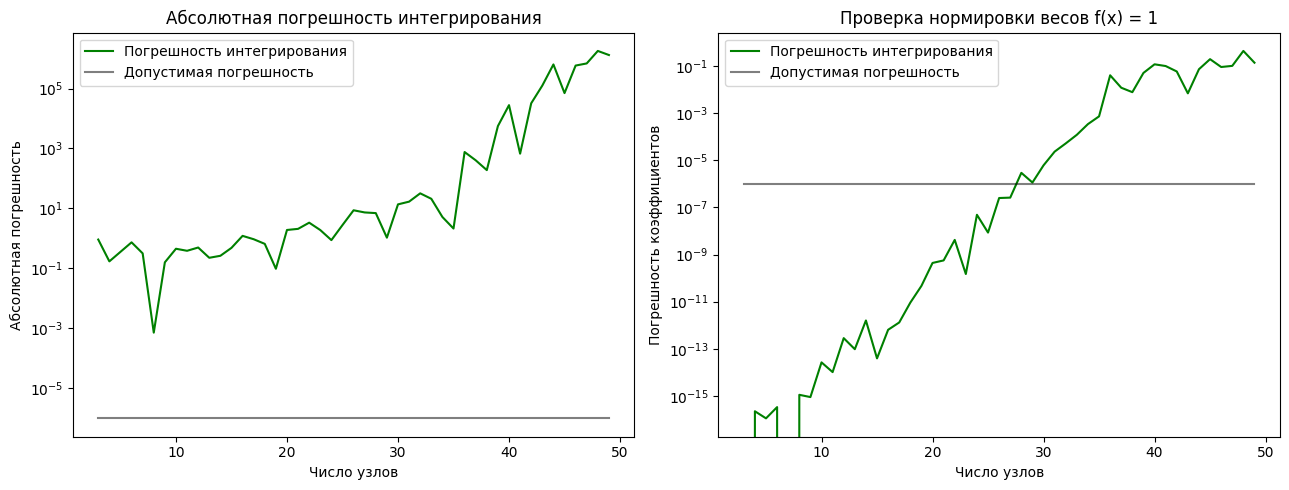

In [ ]:
# проверка нормировки весов
import numpy.testing as npt

def nodes_from_N(a, b, N):
    return np.linspace(a, b, N + 1)

def newton_cotes(xk, a=-1, b=1):
    """
    Вычисляет веса квадратурной формулы Ньютона–Котса
    для узлов xk на интервале [a, b].
    
    Формула будет точна для полиномов степени <= len(xk)-1.
    """

    # переводим узлы в numpy
    xk = np.asarray(xk)

    # число узлов
    m = len(xk)

    # степени полиномов: 0,1,...,m-1
    powers = np.arange(m)

    # матрица Вандермонда
    # W[i,k] = x_k^i
    W = xk[None, :] ** powers[:, None]

    # обратная матрица
    # она переводит базис {x^k} -> базис полиномов Лагранжа
    L = np.linalg.inv(W)

    # степени после интегрирования
    powers = powers + 1

    # интегралы одночленов
    # ∫ x^k dx
    monomial_integrals = (np.power(b,powers) - np.power(a,powers)) / powers

    # веса квадратуры W w = \int x^{j}
    w = L @ monomial_integrals

    return w

I_k = np.zeros(Ns.shape)
for i in range(1, Ns.shape[0]):
    x_k = nodes_from_N(a, b, Ns[i])
    w_k = newton_cotes(x_k, a, b)
    f_k = f(x_k)
    I_k[i] = (np.sum(w_k*f_k))


# проверим нормировку
Ns = np.arange(3, 50)
a = -1
b = 1
eps = 10**(-6)
i_c = 0
sums = np.empty(Ns.shape[0])
for i in range(1, Ns.shape[0]):
    x_k = nodes_from_N(a, b, Ns[i])
    sums[i] = np.abs(np.sum(newton_cotes(x_k, a, b))-(b-a))/2

err_k = sums
err_I = lf.get_abs_err(I*np.ones(I_k.shape), I_k)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))


ax[0].semilogy(Ns, err_I, 'g', label='Погрешность интегрирования')
ax[0].semilogy(Ns, eps*np.ones(Ns.shape[0]), 'k', alpha=0.5, label='Допустимая погрешность')
ax[0].set_xlabel('Число узлов')
ax[0].set_ylabel('Абсолютная погрешность')
ax[0].legend()
ax[0].set_title('Абсолютная погрешность интегрирования')

ax[1].semilogy(Ns, err_k, 'g', label='Погрешность интегрирования')
ax[1].semilogy(Ns, eps*np.ones(Ns.shape[0]), 'k', alpha=0.5, label='Допустимая погрешность')
ax[1].set_xlabel('Число узлов')
ax[1].set_ylabel('Погрешность коэффициентов')
ax[1].set_title('Проверка нормировки весов f(x) = 1')
ax[1].legend()

fig.tight_layout()


##### 5.3 Проверим свойства весов (симметричность) и :

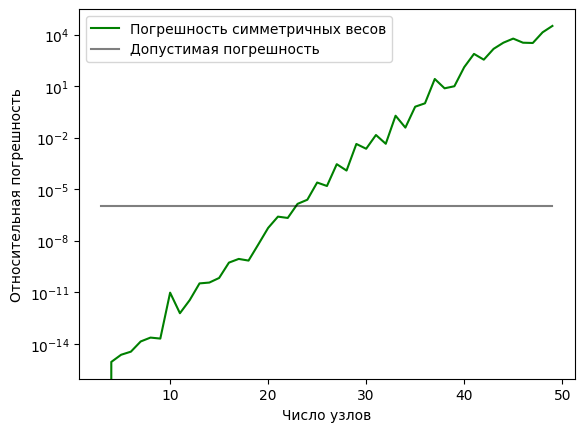

Отрицательные веса появляются для числа узлов [ 9 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33
 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49]


In [10]:
# проверка симметричности весов
sims = np.empty(Ns.shape[0])
mask = np.full(Ns.shape[0], False)
for j in range(Ns.shape[0]):
    ws = newton_cotes(np.linspace(a, b, Ns[j]))
    sims[j] = np.max([np.abs(ws[i-1] - ws[-i])/ws[-i] for i in range(1, 1 + ws.shape[0] // 2)])
    if any(ws < 0):
        mask[j] = True


plt.semilogy(Ns, sims, 'g', label='Погрешность симметричных весов')
plt.semilogy(Ns, eps*np.ones(Ns.shape[0]), 'k', alpha=0.5, label='Допустимая погрешность')
plt.xlabel('Число узлов')
plt.ylabel('Относительная погрешность')
plt.legend()
plt.show()

print(f'Отрицательные веса появляются для числа узлов', Ns[mask])

## Задание 2

Рассмотрим интеграл
$$I = \int_{-1}^5 \frac{dx}{1+9x^2}$$

1. Напишите программу, вычисляющую корни полиномов Лежандра (вам могут пригодиться функции `scipy.special.eval_legendre` и `scipy.optimize.root_scalar`). Найдите веса соответствующей формулы Гаусса. Сравните ваш результат с возвращаемым значением функции `scipy.special.roots_legendre`.

2. Напишите программу, вычисляющую  $I$ с помощью полученной квадратурной формулы. Постройте график погрешности в зависимости от числа узлов. Определите скорость убывания погрешности.

### Решение 2

#### 1.1 Корни полиномов Лежандра

Преабразуем интеграл для численного интегрирования через веса:

$$I = \int_{-1}^5 \frac{dx}{1+9x^2} = \int_{-1}^1 \frac{d(3t)}{1+9(3t + 2)^2} = 3 \cdot \int_{-1}^1 \frac{dt}{1+9(3t + 2)^2}$$

---

После дадим некое определени полиномам Лежандра:

$$P_n(x) = \frac{1}{2^nn!} \frac{d^n}{dx^n}(x^2-1)^n$$
$$\int_{-1}^{1}P_i(x) \cdot P_j(x) dx = \frac{2}{2k + 1}\delta_{ij}$$

---

Получим формулу для весов полиномов Лагранжа:

$$w_i = \int_{-1}^1 l_i(x) dx$$
$$l_i(x) = \prod_{i \neq j}\frac{x - x_j}{x_i - x_j}, \; x_i - \text{корни для полинома $P_n(x)$}$$
$$P_n(x) = C \cdot \prod_{k=1}^{n}(x - x_k) = (x - x_i) \cdot C \cdot \prod_{k \neq i}(x - x_k), \; x_k - \text{корни для полинома $P_n(x)$}$$
$$P_n'(x_i) = C \cdot \prod_{k \neq i}(x_i - x_k)$$
$$l_i(x) = \prod_{i \neq j}\frac{x - x_j}{x_i - x_j} = \frac{P_n(x)}{(x - x_i) \cdot C} \cdot \frac{C}{P_n'(x_i)} = \frac{P_n(x)}{(x - x_i)P_n'(x_i)} $$

Теперь получим выражение для весов, при этом воспользуемся $\frac{P_n(x)}{(x - x_i)} = \sum_{k=0}^{n-1}\alpha_k P_{k}(x)$ (дальнейший вывод не осознан и не понят, пока):
$$w_i = \int_{-1}^1 \frac{P_n(x)}{(x - x_i)P_n'(x_i)} \; dx = \frac{1}{P_n'(x_i)} \int_{-1}^1 P_0(x) \cdot P_{n-1}(x) = \frac{2}{(1 - x_i^2)(P_n'(x_i))^2}$$

---
Далее найдем корни корни уравнений, веса. Сравним с `scipy.special.roots_legendre`

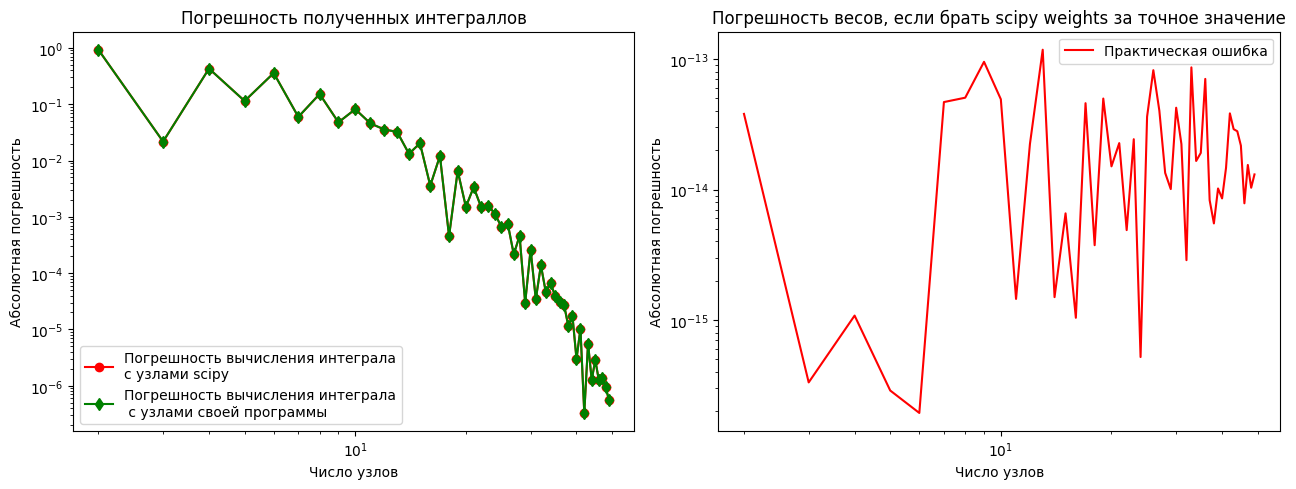

In [ ]:
# вычисление корней полиномов Лежандра
from scipy.special import eval_legendre, roots_legendre
from scipy.optimize import root_scalar

a = -1
b = 1
I = (np.arctan(15)+np.arctan(3))/3

def legendre_derivative(n, x):
    return n*(eval_legendre(n-1,x) - x*eval_legendre(n,x))/(1-x*x)

def find_legendre_roots(n, step, a=-1, b=1):
    """
    Находит корни полинома Лежандра P_n(x) на [a, b].

    Идея:
    1. Строим грубую сетку x_grid.
    2. Вычисляем значения P_n(x) в узлах сетки.
    3. Если на соседних точках знак меняется, значит между ними есть корень.
    4. Уточняем корень методом root_scalar.
    5. Если нашли не все n корней, уменьшаем шаг и повторяем.
    """
    # Сетка для поиска смены знака
    x_grid = np.arange(a, b + step, step)

    # Значения полинома Лежандра P_n в точках сетки
    p_values = eval_legendre(n, x_grid)

    roots = []

    # Ищем интервалы, где функция меняет знак
    for i in range(len(x_grid) - 1):
        left_x = x_grid[i]
        right_x = x_grid[i + 1]

        left_p = p_values[i]
        right_p = p_values[i + 1]

        # Если знаки разные, то между точками есть корень
        if left_p * right_p < 0:
            result = root_scalar(
                lambda x: eval_legendre(n, x),
                bracket=[left_x, right_x]
            )
            roots.append(result.root)

    # Если нашли все n корней, возвращаем их
    if len(roots) == n:
        return np.array(roots)

    # Иначе уменьшаем шаг и ищем снова
    return find_legendre_roots(n, step / 2, a, b)


def get_weights_manual(n, roots):
    return 2/((1 - np.power(roots, 2)) * np.power(legendre_derivative(n, roots), 2))



Ns = np.arange(2, 50)

errors_scipy = np.empty(len(Ns))
errors_manual = np.empty(len(Ns))

errors_manual_weights = np.empty(len(Ns))


for i, n in enumerate(Ns):
    # --------------------------------------------------------
    # Способ 1: готовые узлы и веса из SciPy
    # --------------------------------------------------------
    x_scipy, w_scipy = roots_legendre(n)

    I_scipy = np.dot(f(x_scipy), w_scipy)

    errors_scipy[i] = lf.get_abs_err(I_scipy, I)


    x_manual = find_legendre_roots(n, step=(b - a) / n, a=a, b=b)

    w_manual = get_weights_manual(n, x_manual)

    I_manual = np.dot(f(x_manual), w_manual)

    errors_manual[i] = lf.get_abs_err(I_manual, I)
    errors_manual_weights[i] = np.average(lf.get_abs_err(w_manual, w_scipy))


fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].loglog(Ns, errors_scipy, 'r', marker='o', label='Погрешность вычисления интеграла\n с узлами scipy')
ax[0].loglog(Ns, errors_manual, 'g', marker='d' ,label='Погрешность вычисления интеграла\n с узлами своей программы')
ax[0].set_xlabel('Число узлов')
ax[0].set_ylabel('Абсолютная погрешность')
ax[0].set_title('Погрешность полученных интеграллов')
ax[0].legend()

ax[1].loglog(Ns, errors_manual_weights, 'r', label='Практическая ошибка')
ax[1].set_xlabel('Число узлов')
ax[1].set_ylabel('Абсолютная погрешность')
ax[1].set_title('Погрешность весов, если брать scipy weights за точное значение')
ax[1].legend()

fig.tight_layout()

##  Задание 3.

Рассмотрим интеграл $$I=\int_0^\infty e^{-x}\cos\omega x\,dx.$$
Требуется вычислить интеграл с относительной точностью $10^{-3}$
для $\omega=100,200,500$.

1. Найдите конечный интервал интегрирования, достаточный для вычисления $I$ с заданной точностью.

2. Примение для вычисления $I$ составную формулу Филона (аналог трапеций).
Найдите необходимое для вычисления $I$ с заданной точностью число вычислений подинтегрального выражения.

3. (не обязательно) Найдите $I$ с заданной точностью с помощью формулы Гаусса. Сравните необходимое для этого число вычислений подинтегрального выражения с вычислениями по формуле Филона.

### Решение 3
1. Для нахождения нужного интервала $[0, A]$ рассмотрим 

$$R = \int \limits_A^\infty  e^{-x}\cos\omega x\,dx = \frac12\int \limits_A^\infty  (e^{-x-i\omega x} + e^{-x+i\omega x})\,dx = \frac12\left(\int \limits_A^\infty  e^{-x-i\omega x}\,dx+\int \limits_A^\infty  e^{-x+i\omega x}\,dx\right) =\\= -\frac{1}{2(1+i\omega)}e^{-x-i\omega x}\bigg|_A^\infty-\frac{1}{2(1-i\omega)}e^{-x+i\omega x}\bigg|_A^\infty=\frac{1}{2(1+i\omega)}e^{-A-i\omega A}+\frac{1}{2(1-i\omega)}e^{-A+i\omega A}$$

$$|R|\leq \left|\frac{1}{2(1+i\omega)}e^{-A-i\omega A}\right|+\left|\frac{1}{2(1-i\omega)}e^{-A+i\omega A}\right|=\frac{e^{-A}}{\sqrt{1+\omega^2}}$$


Аналитически $I=\frac{1}{1+\omega^2}$, относительная погрешность:

$$10^{-3}\geq |\frac{R}{I}| = e^{-A}\sqrt{1+\omega^2}\Rightarrow A = \ln{(10^3\sqrt{1+\omega^2})}$$
$\omega = 100: A \geq 11,6\\ \omega = 200: A\geq 12,3\\ \omega = 500: A \geq 13,2$


2. Формула Филона для интеграла на промежутке $[x_i, x_{i+1}], x_i \neq a, x_{i+1} \neq b$:

$$\int \limits_{x_i}^{x_{i+1}} f(x)\cos{(\omega x)} \, dx = \left[f(x)\approx \frac{x-x_i}{x_{i+1}-x_i}f(x_{i+1}) + \frac{x_{i+1}-x}{x_{i+1}-x_i}f(x_i)\right] = \\ = \frac{f(x_{i+1}) - f(x_i)}{\omega^2(x_{i+1}-x_i)}(\cos{\omega x_{i+1}} - \cos{\omega x_i}) - \frac{f(x_{i+1})\sin{\omega x_{i+1}} - f(x_{i})\sin{\omega x_{i}}}{\omega}$$


Составная формула Филона для $N$ узлов (пусть сетка равномерна с шагом $h$):

$$I = \frac{f(a)(\cos{\omega a} - \cos{\omega (a+h)}) + f(b)(\cos{\omega b} - \cos{\omega (b-h)}) }{\omega^2h} + \frac{f(a)\sin{\omega a} - f(b)\sin{\omega b}}{\omega} - \sum \limits_{i=1}^{N-1}\frac{f(x_i)}{\omega^2 h}(\cos{\omega x_{i-1} - 2\cos{\omega x_i} + \cos{\omega x_{i+1}}}$$

In [1]:
a = 0
b = [11.6, 12.3, 13.2]
w = [100, 200, 500]
eps = 10**(-3)

def filon(a, b, n, w):
    h = (b-a)/n
    k = np.arange(n)
    xk = a + k*h
    cosk = np.cos(w*xk)
    f0 = np.sum(np.exp(-xk[1:-1])*(cosk[:-2] - 2*cosk[1:-1] + cosk[2:]))
    return (np.exp(-a)*(cosk[0] - cosk[1]) + np.exp(-b)*(cosk[-1] - cosk[-2]) - f0 + (np.exp(-a)*np.sin(w*a) - np.exp(-b)*np.sin(w*b))*w*h)/w/w/h


def true_I(w):
    return(1/(1 + w**2))

def relative_err(x, x0):
    return np.abs(x - x0) / x0

Ns = np.arange(2, 2000, 5)
errs = np.empty((3, Ns.shape[0]))
for i in range(Ns.shape[0]):
    for j in range(3):
        errs[j, i] = lf.get_abs_err(filon(a, b[j], Ns[i], w[j]), true_I(w[j]))

plt.loglog(Ns, errs[0, :], label=f'$\omega$ = {w[0]}')
plt.loglog(Ns, errs[1, :], label=f'$\omega$ = {w[1]}')
plt.loglog(Ns, errs[2, :], label=f'$\omega$ = {w[2]}')
plt.loglog(Ns, eps * np.ones(Ns.shape[0]), 'k', alpha=0.5, label='Заданная точность')
plt.xlabel('Число узлов')
plt.ylabel('Относительная погрешность')
plt.legend()
plt.show()

<>:27: SyntaxWarning: invalid escape sequence '\o'
<>:28: SyntaxWarning: invalid escape sequence '\o'
<>:29: SyntaxWarning: invalid escape sequence '\o'
<>:27: SyntaxWarning: invalid escape sequence '\o'
<>:28: SyntaxWarning: invalid escape sequence '\o'
<>:29: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_13497/2463256136.py:27: SyntaxWarning: invalid escape sequence '\o'
  plt.loglog(Ns, errs[0, :], label=f'$\omega$ = {w[0]}')
/tmp/ipykernel_13497/2463256136.py:28: SyntaxWarning: invalid escape sequence '\o'
  plt.loglog(Ns, errs[1, :], label=f'$\omega$ = {w[1]}')
/tmp/ipykernel_13497/2463256136.py:29: SyntaxWarning: invalid escape sequence '\o'
  plt.loglog(Ns, errs[2, :], label=f'$\omega$ = {w[2]}')
/tmp/ipykernel_13497/2463256136.py:27: SyntaxWarning: invalid escape sequence '\o'
  plt.loglog(Ns, errs[0, :], label=f'$\omega$ = {w[0]}')
/tmp/ipykernel_13497/2463256136.py:28: SyntaxWarning: invalid escape sequence '\o'
  plt.loglog(Ns, errs[1, :], label=f'$\omega$ = {w[

NameError: name 'np' is not defined